# Advanced Analytics + Risk Metrics

## Task 1 – Historical VaR (95%) & CVaR

Objective:
- Calculate Historical Value at Risk (VaR) at 95%
- Calculate Conditional Value at Risk (CVaR)
- Compute for all 40 schemes

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [10]:
PROJECT_ROOT = Path("..")
DATA_PATH = PROJECT_ROOT/"data"/"processed"

In [11]:
nav = pd.read_csv(DATA_PATH/"02_nav_history_cleaned.csv")

In [12]:
nav.head

<bound method NDFrame.head of        amfi_code        date       nav
0         100016  2022-01-03  520.4608
1         100016  2022-01-04  515.0971
2         100016  2022-01-05  521.7239
3         100016  2022-01-06  515.7880
4         100016  2022-01-07  515.1639
...          ...         ...       ...
45995     149324  2026-05-25  292.4810
45996     149324  2026-05-26  291.2707
45997     149324  2026-05-27  288.8007
45998     149324  2026-05-28  280.6873
45999     149324  2026-05-29  279.7511

[46000 rows x 3 columns]>

In [14]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.5 MB


In [15]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [16]:
nav["date"] = pd.to_datetime(nav["date"])


In [17]:
nav = nav.sort_values(["amfi_code", "date"])

In [51]:
nav["daily_return"] = (nav.groupby("amfi_code")["nav"].pct_change())

In [19]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [20]:
nav = nav.dropna(subset=["daily_return"])

In [21]:
nav.describe()

,amfi_code,date,nav,daily_return
count,45960.000000,45960,45960.000000,45960.000000
mean,120247.000000,2024-03-17 04:46:59.843342,269.624535,0.000631
min,100016.000000,2022-01-04 00:00:00,26.136600,-0.058102
25%,118632.750000,2023-02-09 00:00:00,69.195975,-0.005042
50%,119551.500000,2024-03-18 00:00:00,122.802200,0.000340
75%,120842.250000,2025-04-23 00:00:00,260.426750,0.006324
max,149324.000000,2026-05-29 00:00:00,4268.549700,0.064713
std,14352.317357,NaN,577.252241,0.010290


In [24]:
nav.isnull().sum()

amfi_code       0
date            0
nav             0
daily_return    0
dtype: int64

In [25]:
nav.head()

,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


In [26]:
var_report = (nav.groupby("amfi_code")["daily_return"].quantile(0.05).reset_index().rename(columns={"daily_return": "VaR_95"}))

var_report.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [52]:
def calculate_cvar(group):
    var = group["daily_return"].quantile(0.05)
    cvar = group.loc[group["daily_return"] <= var, "daily_return"].mean()
    return pd.Series({"VaR_95": var,"CVaR_95": cvar})

risk_metrics = (nav.groupby("amfi_code").apply(calculate_cvar).reset_index())

risk_metrics.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014367,-0.018060
1,100025,-0.003794,-0.004994
2,100033,-0.019038,-0.023456
3,101206,-0.013284,-0.017439
4,101207,-0.026023,-0.032459


In [28]:
print(risk_metrics.shape)
risk_metrics.head(10)

(40, 3)


,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459
5,101208,-0.000269,-0.000422
6,102885,-0.012613,-0.015490
7,102886,-0.019220,-0.023251
8,102887,-0.015232,-0.019411
9,118632,-0.013954,-0.017619


In [53]:
OUTPUT_PATH = DATA_PATH

risk_metrics.to_csv(OUTPUT_PATH / "var_cvar_report.csv",index=False)

print("var_cvar_report.csv saved successfully!")

var_cvar_report.csv saved successfully!


In [30]:
top_5_funds = nav["amfi_code"].unique()[:5]

print(top_5_funds)

[100016 100025 100033 101206 101207]


In [54]:
nav["rolling_mean"] = (nav.groupby("amfi_code")["daily_return"].transform(lambda x: x.rolling(window=90).mean()))

In [55]:
nav["rolling_std"] = (nav.groupby("amfi_code")["daily_return"].transform(lambda x: x.rolling(window=90).std()))

In [33]:
nav["rolling_sharpe"] = (
    nav["rolling_mean"] /
    nav["rolling_std"]
) * np.sqrt(252)

In [34]:
nav[[ "amfi_code","date","daily_return","rolling_mean","rolling_std","rolling_sharpe"]].head(100)

,amfi_code,date,daily_return,rolling_mean,rolling_std,rolling_sharpe
1,100016,2022-01-04,-0.010306,NaN,NaN,NaN
2,100016,2022-01-05,0.012865,NaN,NaN,NaN
3,100016,2022-01-06,-0.011377,NaN,NaN,NaN
4,100016,2022-01-07,-0.001210,NaN,NaN,NaN
5,100016,2022-01-10,-0.008639,NaN,NaN,NaN
...,...,...,...,...,...,...
96,100016,2022-05-17,0.026682,-0.000019,0.009981,-0.029988
97,100016,2022-05-18,-0.008220,-0.000083,0.010016,-0.132298
98,100016,2022-05-19,-0.007582,-0.000123,0.010038,-0.194050
99,100016,2022-05-20,-0.004461,-0.000262,0.010010,-0.415433


In [35]:
top5_data = nav[nav["amfi_code"].isin(top_5_funds)]

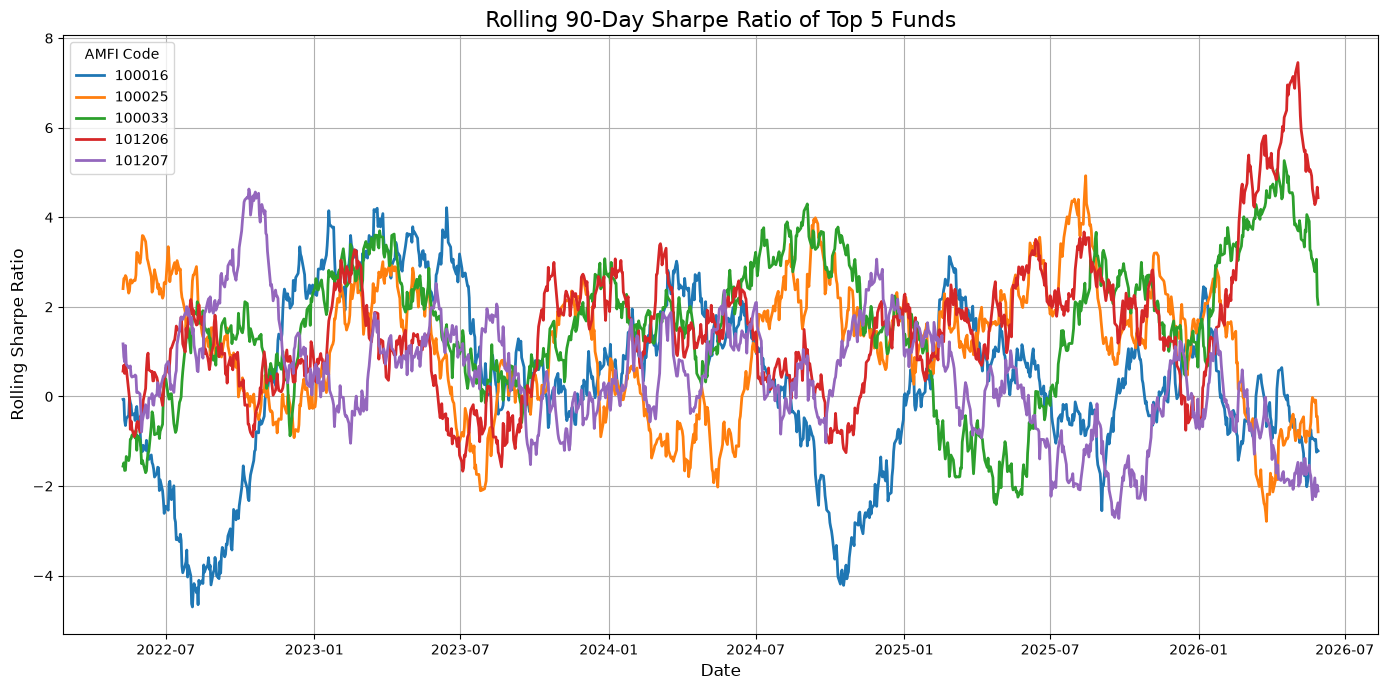

In [57]:
plt.figure(figsize=(14,7))

for fund in top_5_funds:

    fund_data = top5_data[top5_data["amfi_code"] == fund]

    plt.plot(fund_data["date"],fund_data["rolling_sharpe"],linewidth=2,label=str(fund))

plt.title("Rolling 90-Day Sharpe Ratio of Top 5 Funds", fontsize=16)

plt.xlabel("Date", fontsize=12)

plt.ylabel("Rolling Sharpe Ratio", fontsize=12)

plt.grid(True)

plt.legend(title="AMFI Code")

plt.tight_layout()

OUTPUT_REPORT = Path("../reports")

OUTPUT_REPORT.mkdir(exist_ok=True)

plt.savefig(OUTPUT_REPORT / "rolling_sharpe_chart.png",dpi=300,bbox_inches="tight")

plt.show()

In [44]:
investor = pd.read_csv(DATA_PATH / "08_investor_transactions_cleaned.csv")

In [45]:
investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV000081,2024-01-01,120844,Sip,1842,Gujarat,Surat,T30,36-45,Male,31.0,Net Banking,Verified
1,INV000097,2024-01-01,125498,Redemption,527377,Karnataka,Mysore,B30,18-25,Male,6.0,Net Banking,Verified
2,INV000234,2024-01-01,148567,Sip,28094,Tamil Nadu,Coimbatore,B30,26-35,Male,23.8,Mandate,Verified
3,INV000368,2024-01-01,118636,Redemption,339882,Uttar Pradesh,Agra,B30,26-35,Male,16.2,UPI,Verified
4,INV000428,2024-01-01,118636,Sip,9146,Delhi,Gurugram,T30,36-45,Male,27.2,Mandate,Verified


In [47]:
investor.info()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          32778 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 5.4 MB


In [48]:
print(investor.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [50]:
investor["transaction_date"] = pd.to_datetime(investor["transaction_date"])

In [58]:
first_transaction = (investor.groupby("investor_id")["transaction_date"].min().reset_index())

first_transaction.rename(columns={"transaction_date": "first_transaction_date"},inplace=True)

first_transaction.head()

,investor_id,first_transaction_date
0,INV000001,2024-11-04
1,INV000002,2024-03-29
2,INV000003,2024-07-16
3,INV000004,2024-03-16
4,INV000005,2024-04-27


In [59]:
first_transaction["cohort_year"] = (first_transaction["first_transaction_date"].dt.year)

first_transaction.head()

,investor_id,first_transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [60]:
investor = investor.merge(first_transaction[["investor_id", "cohort_year"]],on="investor_id",how="left")

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV000081,2024-01-01,120844,Sip,1842,Gujarat,Surat,T30,36-45,Male,31.0,Net Banking,Verified,2024
1,INV000097,2024-01-01,125498,Redemption,527377,Karnataka,Mysore,B30,18-25,Male,6.0,Net Banking,Verified,2024
2,INV000234,2024-01-01,148567,Sip,28094,Tamil Nadu,Coimbatore,B30,26-35,Male,23.8,Mandate,Verified,2024
3,INV000368,2024-01-01,118636,Redemption,339882,Uttar Pradesh,Agra,B30,26-35,Male,16.2,UPI,Verified,2024
4,INV000428,2024-01-01,118636,Sip,9146,Delhi,Gurugram,T30,36-45,Male,27.2,Mandate,Verified,2024


In [61]:
investor[["investor_id","transaction_date","cohort_year"]].head(10)

,investor_id,transaction_date,cohort_year
0,INV000081,2024-01-01,2024
1,INV000097,2024-01-01,2024
2,INV000234,2024-01-01,2024
3,INV000368,2024-01-01,2024
4,INV000428,2024-01-01,2024
5,INV000437,2024-01-01,2024
6,INV000467,2024-01-01,2024
7,INV000478,2024-01-01,2024
8,INV000488,2024-01-01,2024
9,INV000548,2024-01-01,2024


In [63]:
sip_data = investor[investor["transaction_type"] == "Sip"].copy()

sip_data.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV000081,2024-01-01,120844,Sip,1842,Gujarat,Surat,T30,36-45,Male,31.0,Net Banking,Verified,2024
2,INV000234,2024-01-01,148567,Sip,28094,Tamil Nadu,Coimbatore,B30,26-35,Male,23.8,Mandate,Verified,2024
4,INV000428,2024-01-01,118636,Sip,9146,Delhi,Gurugram,T30,36-45,Male,27.2,Mandate,Verified,2024
5,INV000437,2024-01-01,120504,Sip,900,Telangana,Hyderabad,T30,26-35,Female,6.1,UPI,Verified,2024
6,INV000467,2024-01-01,119552,Sip,2623,Karnataka,Bangalore,T30,18-25,Female,7.1,Cheque,Verified,2024


In [64]:
avg_sip = (sip_data.groupby("cohort_year")["amount_inr"].mean().reset_index().rename(columns={"amount_inr": "avg_sip_amount"}))

avg_sip

,cohort_year,avg_sip_amount
0,2024,10996.885825
1,2025,13505.209581


In [65]:
total_investment = (investor.groupby("cohort_year")["amount_inr"].sum().reset_index().rename(columns={"amount_inr": "total_invested"}))

total_investment

,cohort_year,total_invested
0,2024,3491125187
1,2025,30455243


In [66]:
cohort_summary = avg_sip.merge(total_investment,on="cohort_year",how="inner")

cohort_summary

,cohort_year,avg_sip_amount,total_invested
0,2024,10996.885825,3491125187
1,2025,13505.209581,30455243


In [68]:
fund_preference = sip_data.groupby(["cohort_year", "amfi_code"]).size().reset_index(name="transaction_count")

fund_preference.head()

,cohort_year,amfi_code,transaction_count
0,2024,100016,512
1,2024,100025,447
2,2024,100033,440
3,2024,101206,485
4,2024,101207,532


In [69]:
top_fund = fund_preference.loc[fund_preference.groupby("cohort_year")["transaction_count"].idxmax()]

top_fund

,cohort_year,amfi_code,transaction_count
24,2024,120504,536
62,2025,119599,8


In [71]:
fund_master = pd.read_csv(DATA_PATH / "01_fund_master_cleaned.csv")

fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [72]:
print(fund_master.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [73]:
top_fund = top_fund.merge(fund_master[["amfi_code", "scheme_name", "fund_house"]],on="amfi_code",how="left")

top_fund

,cohort_year,amfi_code,transaction_count,scheme_name,fund_house
0,2024,120504,536,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF
1,2025,119599,8,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund


In [74]:
cohort_summary = cohort_summary.merge(top_fund[["cohort_year", "scheme_name", "fund_house"]],on="cohort_year",how="left")

cohort_summary

,cohort_year,avg_sip_amount,total_invested,scheme_name,fund_house
0,2024,10996.885825,3491125187,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF
1,2025,13505.209581,30455243,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund


In [75]:
sip_data = sip_data.sort_values(["investor_id", "transaction_date"])

sip_data.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19579,INV000001,2024-11-04,120505,Sip,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24395,INV000001,2025-01-19,125497,Sip,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5593,INV000002,2024-03-29,149322,Sip,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
16800,INV000002,2024-09-21,120841,Sip,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
31868,INV000002,2025-05-17,119094,Sip,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024


In [76]:
sip_data["gap_days"] = sip_data.groupby("investor_id")["transaction_date"].diff().dt.days

sip_data.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19579,INV000001,2024-11-04,120505,Sip,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24395,INV000001,2025-01-19,125497,Sip,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5593,INV000002,2024-03-29,149322,Sip,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16800,INV000002,2024-09-21,120841,Sip,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31868,INV000002,2025-05-17,119094,Sip,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0
12614,INV000003,2024-07-16,101207,Sip,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,NaN
27615,INV000003,2025-03-11,149322,Sip,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,238.0
4767,INV000004,2024-03-16,101208,Sip,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6410,INV000004,2024-04-11,119095,Sip,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8218,INV000004,2024-05-09,120844,Sip,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0


In [77]:
sip_count = sip_data.groupby("investor_id").size().reset_index(name="sip_count")

eligible_investors = sip_count[sip_count["sip_count"] >= 6]

eligible_investors.head()

,investor_id,sip_count
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8


In [78]:
sip_data = sip_data.merge(eligible_investors, on="investor_id", how="inner")

sip_data.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days,sip_count
0,INV000004,2024-03-16,101208,Sip,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN,6
1,INV000004,2024-04-11,119095,Sip,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0,6
2,INV000004,2024-05-09,120844,Sip,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0,6
3,INV000004,2024-07-07,148569,Sip,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,59.0,6
4,INV000004,2025-03-29,149324,Sip,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,265.0,6


In [79]:
avg_gap = sip_data.groupby("investor_id")["gap_days"].mean().reset_index(name="avg_gap_days")

avg_gap.head()

,investor_id,avg_gap_days
0,INV000004,85.400000
1,INV000008,70.400000
2,INV000010,64.800000
3,INV000011,40.166667
4,INV000012,57.000000


In [80]:
avg_gap["status"] = np.where(avg_gap["avg_gap_days"] > 35, "At-Risk", "Active")

avg_gap.head()

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At-Risk
1,INV000008,70.400000,At-Risk
2,INV000010,64.800000,At-Risk
3,INV000011,40.166667,At-Risk
4,INV000012,57.000000,At-Risk


In [81]:
avg_gap["status"].value_counts()

status
At-Risk    1332
Active       30
Name: count, dtype: int64

In [82]:
sharpe = pd.read_csv(DATA_PATH / "sharpe_ratio.csv")

print(sharpe.columns.tolist())

['amfi_code', 'mean', 'std', 'Sharpe_Ratio', 'scheme_name']


In [83]:
recommender = sharpe.merge(fund_master[["amfi_code","risk_category"]], on="amfi_code", how="left")

recommender.head()

,amfi_code,mean,std,Sharpe_Ratio,scheme_name,risk_category
0,148567,0.001074,0.008941,1.448291,Mirae Asset Large Cap Fund - Regular - Growth,Moderate
1,120843,0.001082,0.010008,1.306744,Kotak Flexicap Fund - Regular - Growth,Moderately High
2,148569,0.001124,0.011134,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth,High
3,119551,0.000917,0.008656,1.208267,SBI Bluechip Fund - Regular Plan - Growth,Moderate
4,120505,0.001161,0.012152,1.180101,ICICI Pru Midcap Fund - Regular - Growth,High


In [84]:
print(recommender["risk_category"].unique())

<ArrowStringArray>
['Moderate', 'Moderately High', 'High', 'Very High', 'Low']
Length: 5, dtype: str


In [85]:
recommender = recommender.sort_values(["risk_category", "Sharpe_Ratio"], ascending=[True, False])

recommender.head()

,amfi_code,mean,std,Sharpe_Ratio,scheme_name,risk_category
2,148569,0.001124,0.011134,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth,High
4,120505,0.001161,0.012152,1.180101,ICICI Pru Midcap Fund - Regular - Growth,High
5,149323,0.001055,0.011179,1.132122,DSP Midcap Fund - Regular - Growth,High
6,100033,0.001080,0.011929,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,High
10,119094,0.001027,0.012225,0.998231,Axis Midcap Fund - Regular - Growth,High


In [86]:
top3_funds = recommender.groupby("risk_category").head(3)

top3_funds

,amfi_code,mean,std,Sharpe_Ratio,scheme_name,risk_category
2,148569,0.001124,0.011134,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth,High
4,120505,0.001161,0.012152,1.180101,ICICI Pru Midcap Fund - Regular - Growth,High
5,149323,0.001055,0.011179,1.132122,DSP Midcap Fund - Regular - Growth,High
22,120507,0.000268,0.000311,0.495723,ICICI Pru Liquid Fund - Regular - Growth,Low
33,120844,0.000256,0.000323,-0.088747,Kotak Liquid Fund - Regular - Growth,Low
36,119120,0.000222,0.002499,-0.226575,SBI Magnum Gilt Fund - Regular Plan - Growth,Low
0,148567,0.001074,0.008941,1.448291,Mirae Asset Large Cap Fund - Regular - Growth,Moderate
3,119551,0.000917,0.008656,1.208267,SBI Bluechip Fund - Regular Plan - Growth,Moderate
7,118632,0.000865,0.008913,1.081659,Nippon India Large Cap Fund - Regular - Growth,Moderate
1,120843,0.001082,0.010008,1.306744,Kotak Flexicap Fund - Regular - Growth,Moderately High


In [87]:
recommendation_table = top3_funds[["risk_category", "scheme_name", "Sharpe_Ratio"]]

recommendation_table

,risk_category,scheme_name,Sharpe_Ratio
2,High,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930
4,High,ICICI Pru Midcap Fund - Regular - Growth,1.180101
5,High,DSP Midcap Fund - Regular - Growth,1.132122
22,Low,ICICI Pru Liquid Fund - Regular - Growth,0.495723
33,Low,Kotak Liquid Fund - Regular - Growth,-0.088747
36,Low,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.226575
0,Moderate,Mirae Asset Large Cap Fund - Regular - Growth,1.448291
3,Moderate,SBI Bluechip Fund - Regular Plan - Growth,1.208267
7,Moderate,Nippon India Large Cap Fund - Regular - Growth,1.081659
1,Moderately High,Kotak Flexicap Fund - Regular - Growth,1.306744


In [88]:
recommendation_table.to_csv(DATA_PATH / "fund_recommendations.csv", index=False)

print("Recommendation table saved successfully!")

Recommendation table saved successfully!


In [90]:
def recommend_funds(risk):
    result = recommendation_table[recommendation_table["risk_category"] == risk]
    return result

In [93]:
recommend_funds("Low")

,risk_category,scheme_name,Sharpe_Ratio
22,Low,ICICI Pru Liquid Fund - Regular - Growth,0.495723
33,Low,Kotak Liquid Fund - Regular - Growth,-0.088747
36,Low,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.226575


## Advanced Insights

### 1. Historical Risk Analysis
Funds with higher VaR and CVaR values experienced larger downside risk during adverse market conditions. Lower VaR funds were comparatively more stable.

### 2. Risk-Adjusted Performance
Large-cap and diversified equity funds generally achieved higher Rolling Sharpe Ratios, indicating better returns relative to the risk taken.

### 3. Investor Cohort Behaviour
The 2024 investor cohort contributed the highest total investment and maintained a higher average SIP amount compared to the 2025 cohort.

### 4. SIP Continuity
Most investors maintained regular SIP investments, while investors with an average transaction gap greater than 35 days were identified as At-Risk and may require engagement to improve continuity.

### 5. Fund Recommendation
The recommendation engine successfully identified the top three funds within each risk category based on Sharpe Ratio, enabling investors to choose funds according to their risk appetite.

In [98]:
portfolio= pd.read_csv(DATA_PATH / "09_portfolio_holdings_cleaned.csv")

In [99]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,100016,BAJFINANCE,Bajaj Finance Ltd,NBFC,7.01,214.89,592.41,2025-12-31
1,100016,CIPLA,Cipla Ltd,Pharma,4.92,1325.34,4188.12,2025-12-31
2,100016,DRREDDY,Dr. Reddy's Laboratories,Pharma,9.03,452.67,2212.60,2025-12-31
3,100016,HINDUNILVR,Hindustan Unilever Ltd,FMCG,11.68,1590.03,2555.06,2025-12-31
4,100016,ICICIBANK,ICICI Bank Ltd,Banking,3.39,169.92,4888.66,2025-12-31


In [100]:
print(portfolio.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [101]:
portfolio["weight"] = portfolio["weight_pct"] / 100

portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,weight
0,100016,BAJFINANCE,Bajaj Finance Ltd,NBFC,7.01,214.89,592.41,2025-12-31,0.0701
1,100016,CIPLA,Cipla Ltd,Pharma,4.92,1325.34,4188.12,2025-12-31,0.0492
2,100016,DRREDDY,Dr. Reddy's Laboratories,Pharma,9.03,452.67,2212.60,2025-12-31,0.0903
3,100016,HINDUNILVR,Hindustan Unilever Ltd,FMCG,11.68,1590.03,2555.06,2025-12-31,0.1168
4,100016,ICICIBANK,ICICI Bank Ltd,Banking,3.39,169.92,4888.66,2025-12-31,0.0339


In [102]:
portfolio["weight_square"] = portfolio["weight"] ** 2

portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,weight,weight_square
0,100016,BAJFINANCE,Bajaj Finance Ltd,NBFC,7.01,214.89,592.41,2025-12-31,0.0701,0.004914
1,100016,CIPLA,Cipla Ltd,Pharma,4.92,1325.34,4188.12,2025-12-31,0.0492,0.002421
2,100016,DRREDDY,Dr. Reddy's Laboratories,Pharma,9.03,452.67,2212.60,2025-12-31,0.0903,0.008154
3,100016,HINDUNILVR,Hindustan Unilever Ltd,FMCG,11.68,1590.03,2555.06,2025-12-31,0.1168,0.013642
4,100016,ICICIBANK,ICICI Bank Ltd,Banking,3.39,169.92,4888.66,2025-12-31,0.0339,0.001149


In [103]:
hhi = portfolio.groupby("amfi_code")["weight_square"].sum().reset_index()

hhi.rename(columns={"weight_square":"HHI"}, inplace=True)

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [111]:
hhi = hhi.merge(fund_master[["amfi_code","category"]], on="amfi_code", how="left")

hhi.head()

,amfi_code,HHI,scheme_name,category
0,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Equity
1,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
2,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Equity
3,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity
4,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Equity


In [112]:
print(hhi.columns.tolist())

['amfi_code', 'HHI', 'scheme_name', 'category']


In [113]:
equity_hhi = hhi[hhi["category"].str.contains("Equity", case=False, na=False)].copy()

equity_hhi.head()

,amfi_code,HHI,scheme_name,category
0,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Equity
1,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
2,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Equity
3,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity
4,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Equity


In [114]:
equity_hhi = equity_hhi.sort_values("HHI", ascending=False)

equity_hhi.head(10)

,amfi_code,HHI,scheme_name,category
0,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Equity
1,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
2,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Equity
3,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity
4,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Equity
5,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity
6,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,Equity
7,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
8,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
9,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Equity


In [115]:
equity_hhi.to_csv(DATA_PATH / "sector_hhi_report.csv", index=False)

print("Sector HHI Report Saved Successfully!")

Sector HHI Report Saved Successfully!
